### Cancellation model experiments
* run on the real 2015 to 2017 bookings of the two hotels, kept as the reference of what the real data supports
* feature sets, model families, calibration and landmark sampling compared on the same time based protocol
* two snapshot dates, evaluation on the books at the snapshot, on bookings created afterwards and on arrivals of the next eight weeks
* learning curves of every boosted configuration, train against validation per iteration
* results table printed at the end

In [1]:
import os
import sys
import json
import time
import datetime
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
warnings.filterwarnings("ignore")

In [2]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, ROOT_DIR)

from app.models import context
from app.models import features

In [3]:
# paths and protocol parameters
PARQUET_PATH = os.path.join(ROOT_DIR, "data", "parquet", "bookings.parquet")
WEATHER_PATH = os.path.join(ROOT_DIR, "data", "parquet", "weather.parquet")
HOLIDAYS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "holidays.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
snapshots = [pd.Timestamp("2016-06-22"), pd.Timestamp("2016-11-01")]
validation_share = 0.1
samples_per_booking = 2
near_days = 56
rng = np.random.default_rng(7)
new_features = ["same_day_clones", "agent_prior_rate", "agent_prior_n", "country_prior_rate", "rel_price", "is_portugal", "total_guests", "weekend_share", "prev_cancel_ratio"]
base_params = {"objective": "binary", "metric": ["binary_logloss", "auc"], "learning_rate": 0.03, "num_leaves": 63, "min_data_in_leaf": 40, "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 1.0, "verbose": -1, "num_threads": 3, "seed": 7}
search_space = [
    {"num_leaves": 31, "min_data_in_leaf": 100, "learning_rate": 0.03, "feature_fraction": 0.7, "lambda_l2": 5.0},
    {"num_leaves": 127, "min_data_in_leaf": 40, "learning_rate": 0.02, "feature_fraction": 0.8, "lambda_l2": 1.0},
    {"num_leaves": 63, "min_data_in_leaf": 200, "learning_rate": 0.03, "feature_fraction": 0.6, "lambda_l2": 10.0},
    {"num_leaves": 255, "min_data_in_leaf": 80, "learning_rate": 0.02, "feature_fraction": 0.7, "lambda_l2": 3.0, "min_gain_to_split": 0.01},
    {"num_leaves": 63, "min_data_in_leaf": 40, "learning_rate": 0.05, "feature_fraction": 0.9, "lambda_l2": 0.0, "max_depth": 8},
    {"num_leaves": 47, "min_data_in_leaf": 60, "learning_rate": 0.03, "feature_fraction": 0.75, "lambda_l2": 2.0, "extra_trees": True},
]

In [4]:
# load the staged bookings and the context tables
def load_all():
    frame = pd.read_parquet(PARQUET_PATH)
    for col in ["arrival_date", "booking_date", "leave_books_date"]:
        frame[col] = pd.to_datetime(frame[col])
    weather = pd.read_parquet(WEATHER_PATH)
    holidays = pd.read_parquet(HOLIDAYS_PATH)
    return frame, weather, holidays

In [5]:
# training rows are complete arrival cohorts, evaluation rows are on the books, created later and arriving soon
def split_as_of(frame, snapshot):
    resolved = frame[frame["arrival_date"] <= snapshot]
    on_books = frame[(frame["booking_date"] <= snapshot) & (frame["leave_books_date"] > snapshot)]
    future = frame[frame["booking_date"] > snapshot]
    near = frame[(frame["arrival_date"] > snapshot) & (frame["arrival_date"] <= snapshot + pd.Timedelta(days=near_days))]
    return resolved, on_books, future, near

In [6]:
# split resolved rows into train and validation by booking id
def split_validation(resolved, share):
    ids = resolved["booking_id"].unique()
    valid_ids = rng.choice(ids, size=int(len(ids) * share), replace=False)
    mask = resolved["booking_id"].isin(valid_ids)
    return resolved[~mask], resolved[mask]

In [7]:
# expand bookings into as of observations at random dates between booking and departure from the books
def landmark(frame, k):
    parts = []
    for i in range(k):
        out = frame.copy()
        span = (out["leave_books_date"].clip(upper=out["arrival_date"]) - out["booking_date"]).dt.days.clip(lower=0)
        offset = np.floor(rng.random(len(out)) * (span.values + 1))
        out["as_of"] = out["booking_date"] + pd.to_timedelta(offset, unit="D")
        parts.append(out)
    return pd.concat(parts, ignore_index=True)

In [8]:
# observe a frame at one fixed date or at each row's booking date
def observe_at(frame, date):
    out = frame.copy()
    out["as_of"] = date
    return out

In [9]:
# feature matrix for a feature set, dropping the new features for the baseline set
def matrix(frame, levels, feature_set):
    x = features.transform(frame, levels)
    if feature_set == "baseline":
        x = x.drop(columns=[c for c in new_features if c in x.columns])
    return x

In [10]:
# expected calibration error with ten equal width bins
def ece(p, y, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    total = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (p >= lo) & (p < hi)
        if mask.sum() == 0:
            continue
        total = total + mask.mean() * abs(p[mask].mean() - y[mask].mean())
    return float(total)

In [11]:
# discrimination and probability quality
def evaluate(p, y):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return {"rows": int(len(y)), "base_rate": round(float(y.mean()), 4), "roc_auc": round(float(roc_auc_score(y, p)), 4), "pr_auc": round(float(average_precision_score(y, p)), 4), "brier": round(float(brier_score_loss(y, p)), 4), "brier_base": round(float(brier_score_loss(y, np.full(len(y), y.mean()))), 4), "log_loss": round(float(log_loss(y, p)), 4), "ece": round(ece(p, y), 4)}

In [12]:
# lightgbm with early stopping on the validation slice, loss and auc recorded per iteration on both sets
def fit_lgbm(x_train, y_train, x_valid, y_valid, overrides):
    params = dict(base_params)
    params.update(overrides)
    d_train = lgb.Dataset(x_train, label=y_train)
    d_valid = lgb.Dataset(x_valid, label=y_valid, reference=d_train)
    history = {}
    callbacks = [lgb.early_stopping(150, first_metric_only=True, verbose=False), lgb.record_evaluation(history)]
    model = lgb.train(params, d_train, num_boost_round=4000, valid_sets=[d_train, d_valid], valid_names=["train", "validation"], callbacks=callbacks)
    curve = {"iteration": list(range(1, len(history["train"]["binary_logloss"]) + 1)), "train_loss": history["train"]["binary_logloss"], "test_loss": history["validation"]["binary_logloss"], "train_auc": history["train"]["auc"], "test_auc": history["validation"]["auc"], "best_iteration": model.best_iteration}
    return model, (lambda x: model.predict(x)), curve

In [13]:
# catboost with native categorical handling and early stopping, loss and auc recorded per iteration on both sets
def fit_catboost(x_train, y_train, x_valid, y_valid):
    cat_cols = [c for c in x_train.columns if str(x_train[c].dtype) == "category"]
    xt = x_train.copy()
    xv = x_valid.copy()
    for c in cat_cols:
        xt[c] = xt[c].astype(str)
        xv[c] = xv[c].astype(str)
    model = CatBoostClassifier(iterations=3000, learning_rate=0.05, depth=8, l2_leaf_reg=3, loss_function="Logloss", eval_metric="Logloss", custom_metric=["AUC:hints=skip_train~false"], od_type="Iter", od_wait=150, random_seed=7, thread_count=3, verbose=False)
    model.fit(xt, y_train, cat_features=cat_cols, eval_set=(xv, y_valid))
    evals = model.get_evals_result()
    auc_key = [k for k in evals["learn"] if k.startswith("AUC")][0]
    curve = {"iteration": list(range(1, len(evals["learn"]["Logloss"]) + 1)), "train_loss": evals["learn"]["Logloss"], "test_loss": evals["validation"]["Logloss"], "train_auc": evals["learn"][auc_key], "test_auc": evals["validation"][auc_key], "best_iteration": int(model.get_best_iteration()) + 1}
    def predict(x):
        xx = x.copy()
        for c in cat_cols:
            xx[c] = xx[c].astype(str)
        return model.predict_proba(xx)[:, 1]
    return model, predict, curve

In [14]:
# regularised logistic regression on one hot categories and scaled numbers, no iteration curve
def fit_logistic(x_train, y_train):
    cat_cols = [c for c in x_train.columns if str(x_train[c].dtype) == "category"]
    num_cols = [c for c in x_train.columns if c not in cat_cols]
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), cat_cols), ("num", StandardScaler(), num_cols)])
    model = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=3000, C=0.5))])
    xt = x_train.copy()
    for c in cat_cols:
        xt[c] = xt[c].astype(str)
    model.fit(xt, y_train)
    def predict(x):
        xx = x.copy()
        for c in cat_cols:
            xx[c] = xx[c].astype(str)
        return model.predict_proba(xx)[:, 1]
    return model, predict, None

In [15]:
# isotonic calibration on the validation slice
def calibrate(p_valid, y_valid):
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_valid, y_valid)
    return iso

In [16]:
# run one configuration on one snapshot and return the metrics per evaluation set, the predictions and the learning curve
def run_config(name, feature_set, fit, data, k):
    train, valid, sets, weather, holidays = data
    train_k = context.add_context(landmark(train, k), weather, holidays)
    valid_k = context.add_context(landmark(valid, k), weather, holidays)
    levels = features.fit_levels(train_k)
    x_train = matrix(train_k, levels, feature_set)
    x_valid = matrix(valid_k, levels, feature_set)
    t0 = time.time()
    model, predict, curve = fit(x_train, train_k["is_canceled"].values, x_valid, valid_k["is_canceled"].values)
    iso = calibrate(predict(x_valid), valid_k["is_canceled"].values)
    out = {"name": name, "features": feature_set, "k": k, "seconds": round(time.time() - t0)}
    preds = {}
    for label, frame in sets.items():
        p = iso.predict(predict(matrix(frame, levels, feature_set)))
        preds[label] = p
        out[label] = evaluate(p, frame["is_canceled"].values)
    return out, preds, curve

In [17]:
# average calibrated probabilities of several configurations
def ensemble(name, members, sets):
    out = {"name": name, "features": "engineered", "k": samples_per_booking, "seconds": 0}
    for label, frame in sets.items():
        p = np.mean([preds[label] for preds in members], axis=0)
        out[label] = evaluate(p, frame["is_canceled"].values)
    return out

In [18]:
# prepare the data for one snapshot
def prepare(frame, weather, holidays, snapshot):
    resolved, on_books, future, near = split_as_of(frame, snapshot)
    train, valid = split_validation(resolved, validation_share)
    sets = {"on_books": context.add_context(observe_at(on_books, snapshot), weather, holidays), "future": context.add_context(observe_at(future, future["booking_date"]), weather, holidays), "near_arrivals": context.add_context(observe_at(near, near["booking_date"]), weather, holidays)}
    return train, valid, sets, weather, holidays

In [19]:
# flatten results into a table with the main metrics per evaluation set
def results_table(results):
    rows = []
    for r in results:
        row = {"snapshot": r["snapshot"], "name": r["name"], "features": r["features"], "k": r["k"], "seconds": r["seconds"]}
        for label in ["on_books", "future", "near_arrivals"]:
            row[label + "_auc"] = r[label]["roc_auc"]
            row[label + "_brier"] = r[label]["brier"]
            row[label + "_ece"] = r[label]["ece"]
        rows.append(row)
    return pd.DataFrame(rows)

In [20]:
# learning curves, train against validation per boosting iteration for the loss and for auc
def plot_learning_curves(curve):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(curve["iteration"], curve["train_loss"], color="blue", label="train")
    axes[0].plot(curve["iteration"], curve["test_loss"], color="red", label="validation")
    axes[0].axvline(curve["best_iteration"], color="gray", linestyle="--", label="best iteration")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("log loss")
    axes[0].legend()
    axes[1].plot(curve["iteration"], curve["train_auc"], color="blue", label="train")
    axes[1].plot(curve["iteration"], curve["test_auc"], color="red", label="validation")
    axes[1].axvline(curve["best_iteration"], color="gray", linestyle="--", label="best iteration")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("roc auc")
    axes[1].legend()
    fig.suptitle("Learning curves")
    plt.tight_layout()
    plt.show()

In [21]:
frame, weather, holidays = load_all()
frame = frame[(frame["adr"] >= 0) & (frame["adr"] < 1000)]
print("bookings after rate cleaning " + str(len(frame)))
results = []
stored = {}
curves = {}
for snapshot in snapshots:
    data = prepare(frame, weather, holidays, snapshot)
    print("snapshot " + str(snapshot.date()) + ", train " + str(len(data[0])) + ", valid " + str(len(data[1])) + ", on books " + str(len(data[2]["on_books"])) + ", future " + str(len(data[2]["future"])) + ", near arrivals " + str(len(data[2]["near_arrivals"])))
    configs = [("lgbm default", "baseline", lambda a, b, c, d: fit_lgbm(a, b, c, d, {})), ("lgbm default", "engineered", lambda a, b, c, d: fit_lgbm(a, b, c, d, {}))]
    for i, space in enumerate(search_space):
        configs.append(("lgbm search " + str(i + 1), "engineered", (lambda s: (lambda a, b, c, d: fit_lgbm(a, b, c, d, s)))(space)))
    configs.append(("catboost", "engineered", fit_catboost))
    configs.append(("logistic", "engineered", lambda a, b, c, d: fit_logistic(a, b)))
    for name, feature_set, fit in configs:
        r, preds, curve = run_config(name, feature_set, fit, data, samples_per_booking)
        r["snapshot"] = str(snapshot.date())
        results.append(r)
        stored[(str(snapshot.date()), name, feature_set)] = preds
        curves[(str(snapshot.date()), name, feature_set, samples_per_booking)] = curve
        print(str(snapshot.date()) + " " + name + " " + feature_set + " future auc " + str(r["future"]["roc_auc"]) + " brier " + str(r["future"]["brier"]) + " near auc " + str(r["near_arrivals"]["roc_auc"]) + " in " + str(r["seconds"]) + " s")

bookings after rate cleaning 119388


snapshot 2016-06-22, train 43069, valid 4785, on books 12395, future 53864, near arrivals 8664


2016-06-22 lgbm default baseline future auc 0.8333 brier 0.1731 near auc 0.8599 in 27 s


2016-06-22 lgbm default engineered future auc 0.8736 brier 0.1472 near auc 0.9194 in 23 s


2016-06-22 lgbm search 1 engineered future auc 0.8715 brier 0.1486 near auc 0.9184 in 35 s


...

2016-11-01 lgbm search 4 engineered future auc 0.8927 brier 0.1489 near auc 0.9157 in 51 s


2016-11-01 lgbm search 5 engineered future auc 0.8864 brier 0.1617 near auc 0.9134 in 37 s


2016-11-01 lgbm search 6 engineered future auc 0.89 brier 0.1574 near auc 0.9132 in 117 s


2016-11-01 catboost engineered future auc 0.8832 brier 0.1503 near auc 0.9138 in 707 s


2016-11-01 logistic engineered future auc 0.8605 brier 0.1856 near auc 0.8852 in 8 s


In [22]:
for snapshot in snapshots:
    key = str(snapshot.date())
    data = prepare(frame, weather, holidays, snapshot)
    searches = [r for r in results if r["snapshot"] == key and r["name"].startswith("lgbm search")]
    best = sorted(searches, key=lambda r: r["future"]["log_loss"])[0]["name"]
    members = [stored[(key, best, "engineered")], stored[(key, "catboost", "engineered")]]
    r = ensemble("ensemble lgbm + catboost", members, data[2])
    r["snapshot"] = key
    results.append(r)
    members3 = members + [stored[(key, "logistic", "engineered")]]
    r = ensemble("ensemble lgbm + catboost + logistic", members3, data[2])
    r["snapshot"] = key
    results.append(r)
    print(key + " best search " + best)

2016-06-22 best search lgbm search 1


2016-11-01 best search lgbm search 4


In [23]:
snapshot = snapshots[0]
data = prepare(frame, weather, holidays, snapshot)
best = sorted([r for r in results if r["snapshot"] == str(snapshot.date()) and r["name"].startswith("lgbm search")], key=lambda r: r["future"]["log_loss"])[0]["name"]
space = search_space[int(best.split(" ")[-1]) - 1]
for k in [1, 3]:
    r, preds, curve = run_config("lgbm best, k " + str(k), "engineered", lambda a, b, c, d: fit_lgbm(a, b, c, d, space), data, k)
    r["snapshot"] = str(snapshot.date())
    results.append(r)
    curves[(str(snapshot.date()), "lgbm best, k " + str(k), "engineered", k)] = curve
    print("k " + str(k) + " future auc " + str(r["future"]["roc_auc"]) + " brier " + str(r["future"]["brier"]))

k 1 future auc 0.8709 brier 0.1496


k 3 future auc 0.8718 brier 0.1472


snapshot 2016-06-22, lgbm default, baseline features, k 2, best iteration 933, validation log loss at best 0.1652, train 0.0728


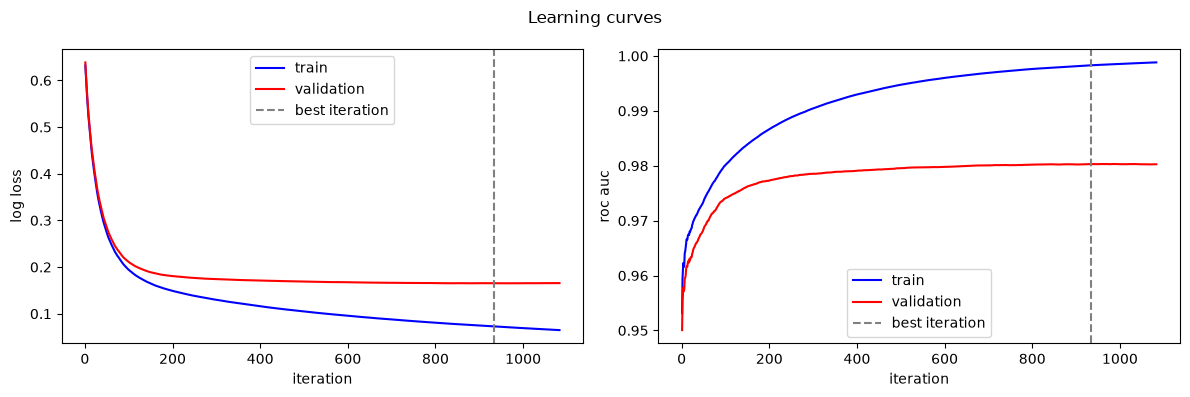

snapshot 2016-06-22, lgbm default, engineered features, k 2, best iteration 719, validation log loss at best 0.1599, train 0.078


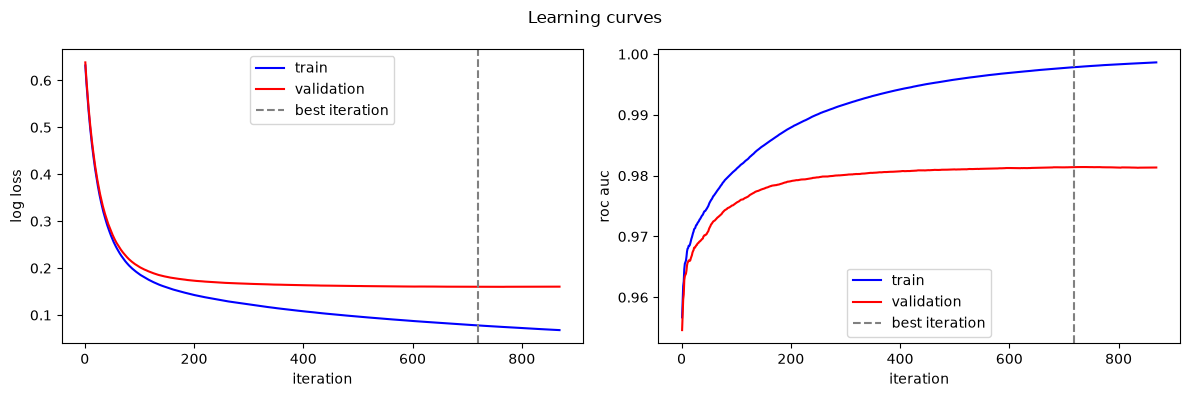

snapshot 2016-06-22, lgbm search 1, engineered features, k 2, best iteration 1532, validation log loss at best 0.1652, train 0.0865


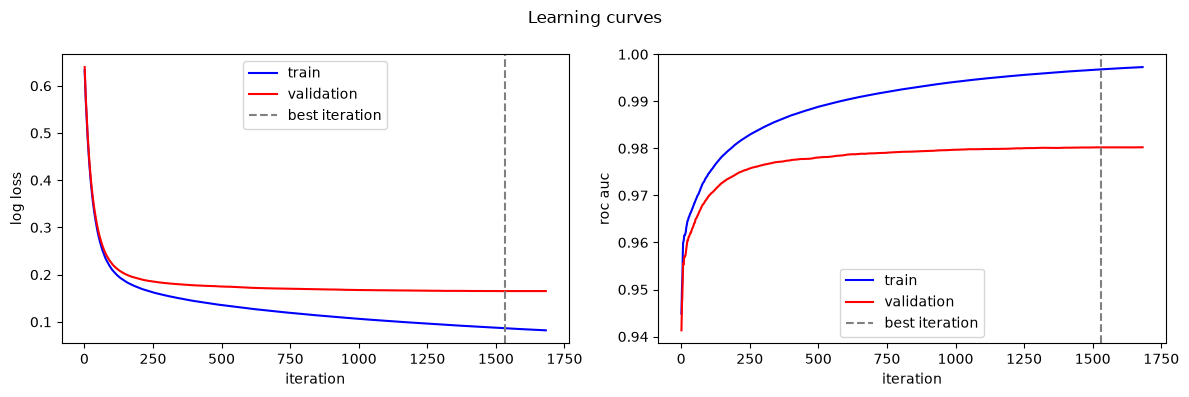

snapshot 2016-06-22, lgbm search 2, engineered features, k 2, best iteration 740, validation log loss at best 0.1575, train 0.0606


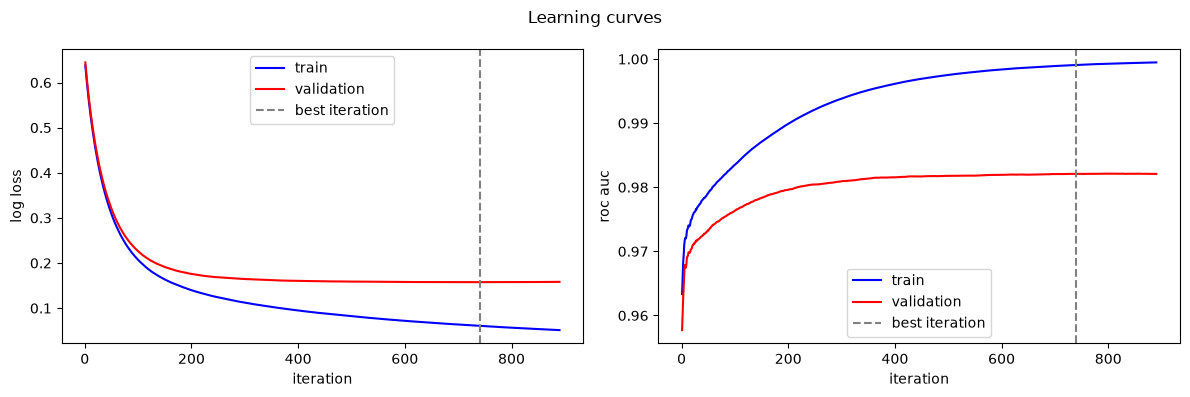

snapshot 2016-06-22, lgbm search 3, engineered features, k 2, best iteration 866, validation log loss at best 0.1634, train 0.0843


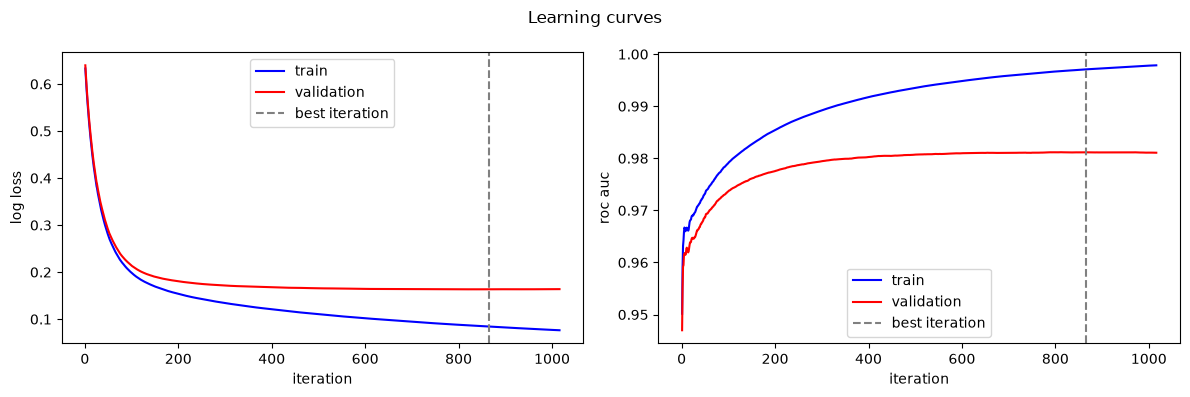

snapshot 2016-06-22, lgbm search 4, engineered features, k 2, best iteration 439, validation log loss at best 0.1623, train 0.0697


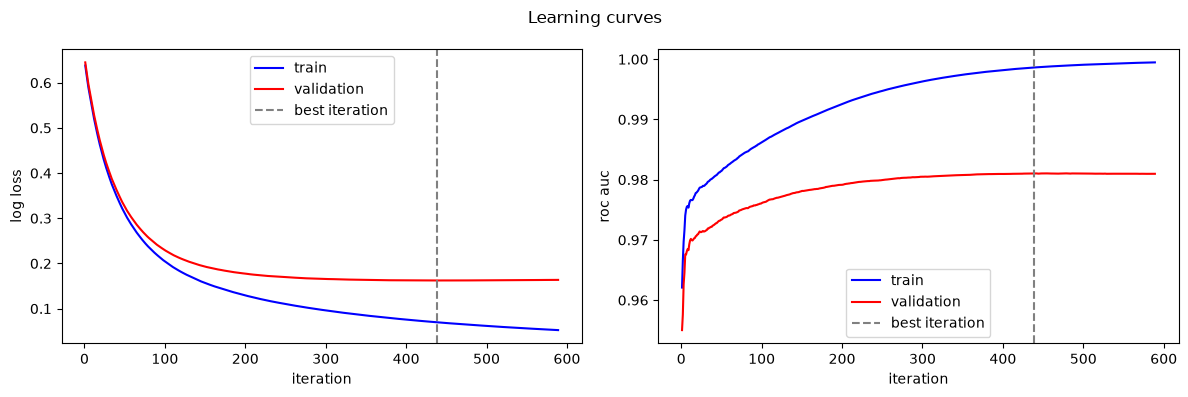

snapshot 2016-06-22, lgbm search 5, engineered features, k 2, best iteration 500, validation log loss at best 0.1629, train 0.0762


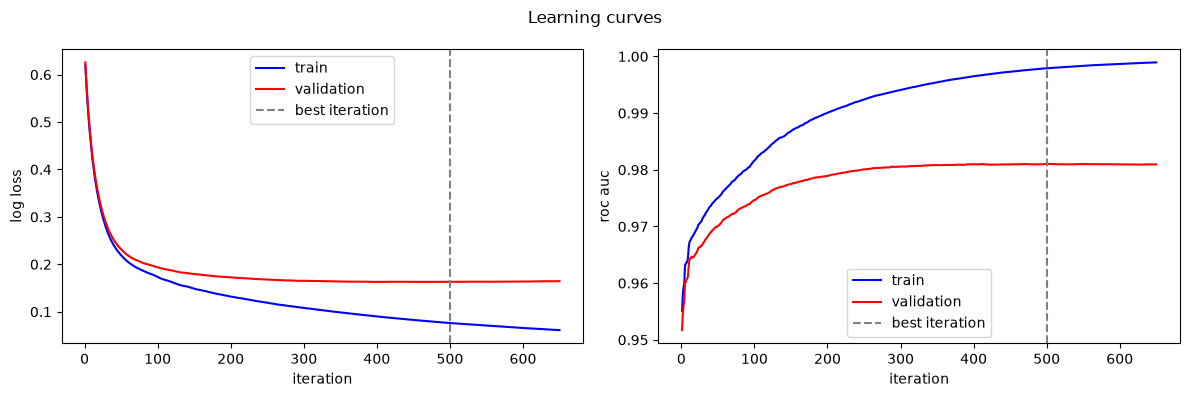

snapshot 2016-06-22, lgbm search 6, engineered features, k 2, best iteration 1523, validation log loss at best 0.1656, train 0.0982


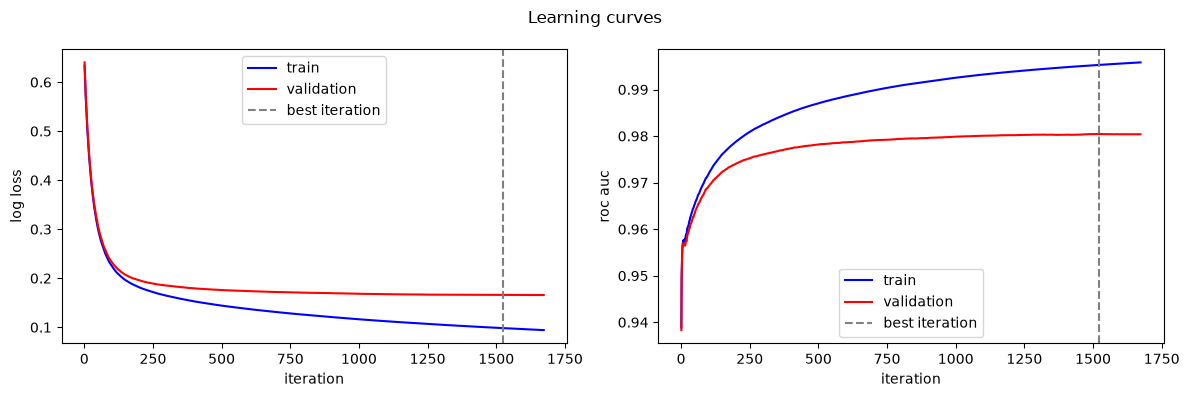

snapshot 2016-06-22, catboost, engineered features, k 2, best iteration 1413, validation log loss at best 0.1655, train 0.0716


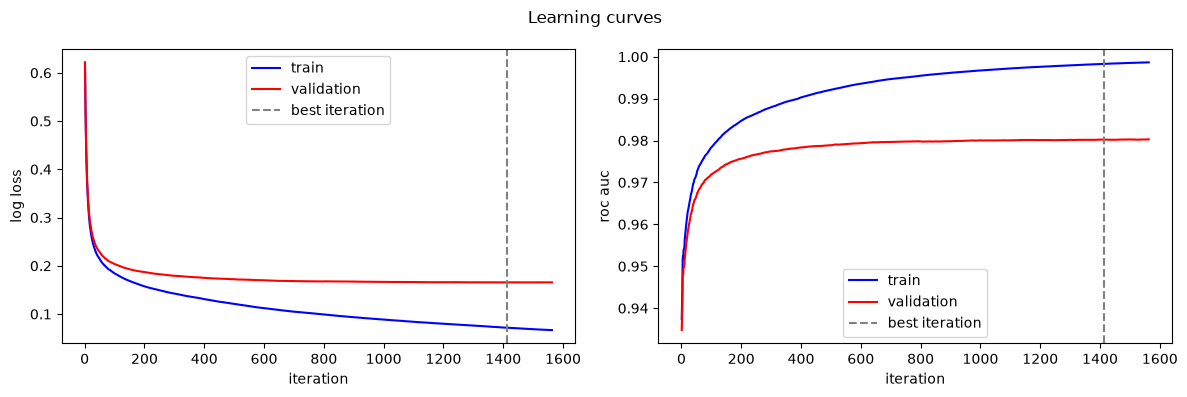

snapshot 2016-11-01, lgbm default, baseline features, k 2, best iteration 1215, validation log loss at best 0.179, train 0.094


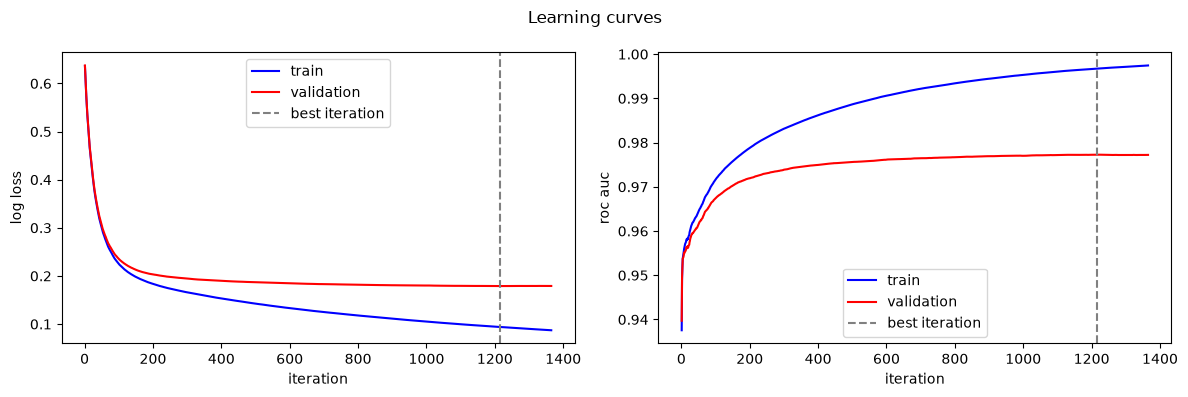

snapshot 2016-11-01, lgbm default, engineered features, k 2, best iteration 1385, validation log loss at best 0.1755, train 0.0741


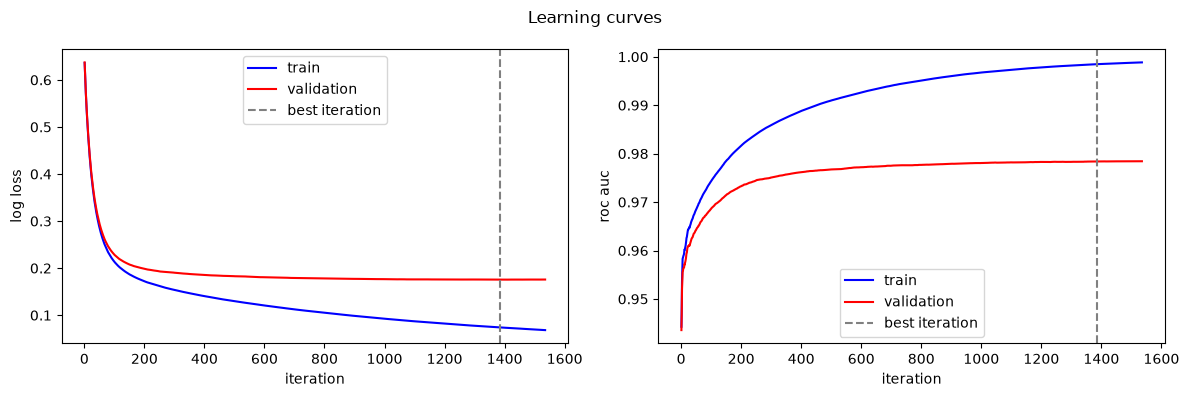

snapshot 2016-11-01, lgbm search 1, engineered features, k 2, best iteration 2755, validation log loss at best 0.1734, train 0.0888


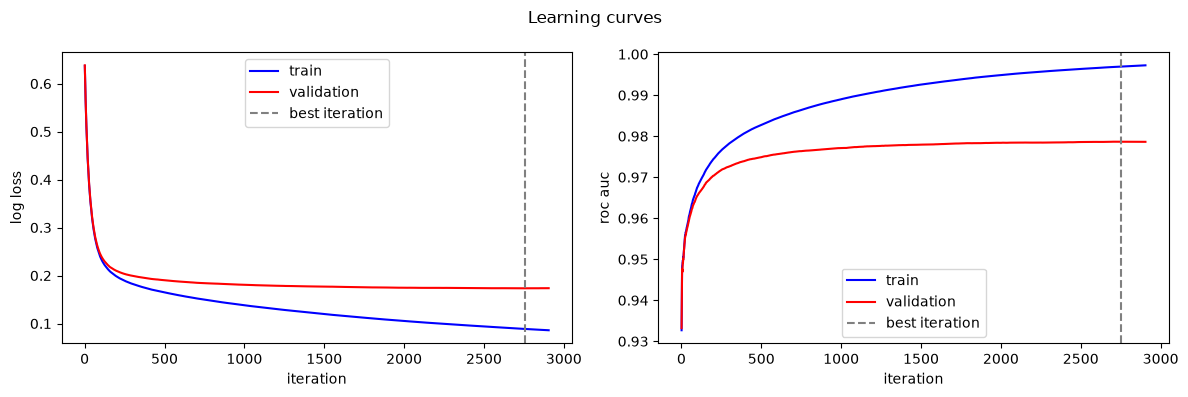

snapshot 2016-11-01, lgbm search 2, engineered features, k 2, best iteration 1149, validation log loss at best 0.1704, train 0.0677


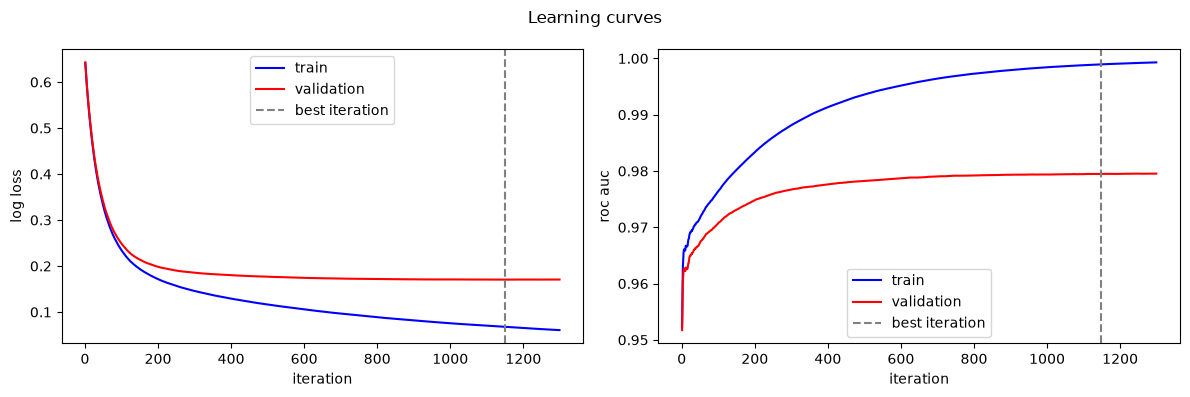

snapshot 2016-11-01, lgbm search 3, engineered features, k 2, best iteration 1680, validation log loss at best 0.1733, train 0.0823


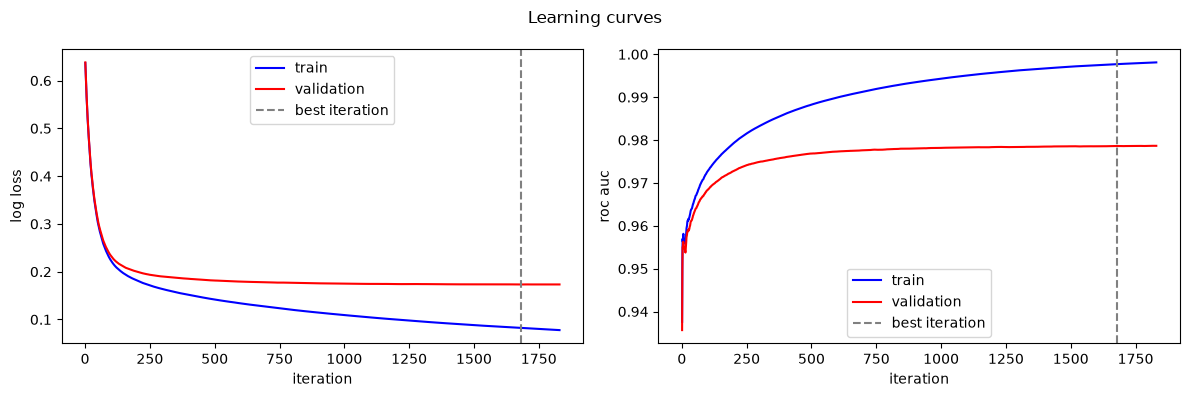

snapshot 2016-11-01, lgbm search 4, engineered features, k 2, best iteration 665, validation log loss at best 0.1699, train 0.0701


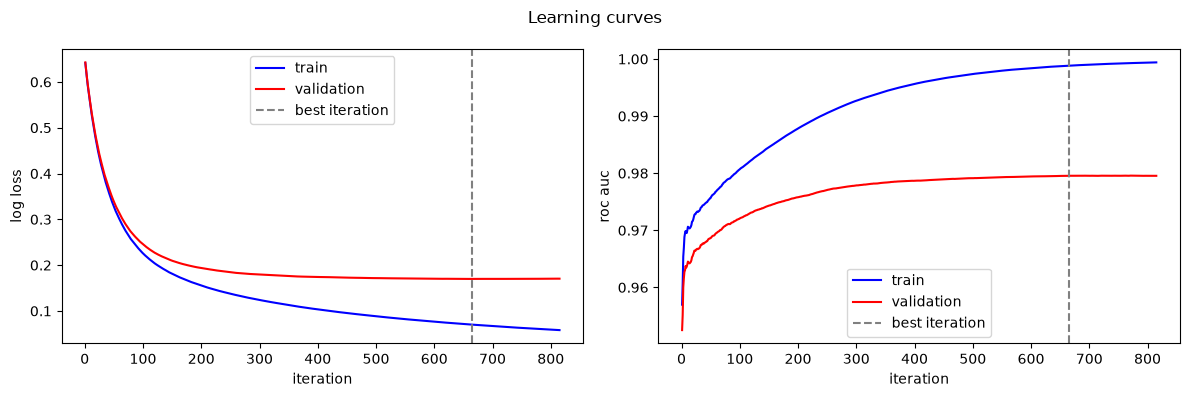

snapshot 2016-11-01, lgbm search 5, engineered features, k 2, best iteration 827, validation log loss at best 0.1761, train 0.08


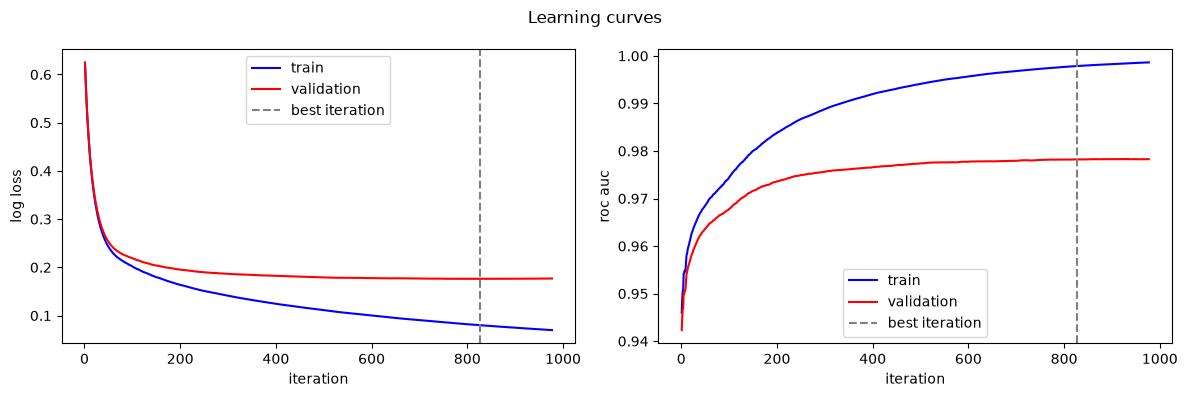

snapshot 2016-11-01, lgbm search 6, engineered features, k 2, best iteration 3223, validation log loss at best 0.1786, train 0.0946


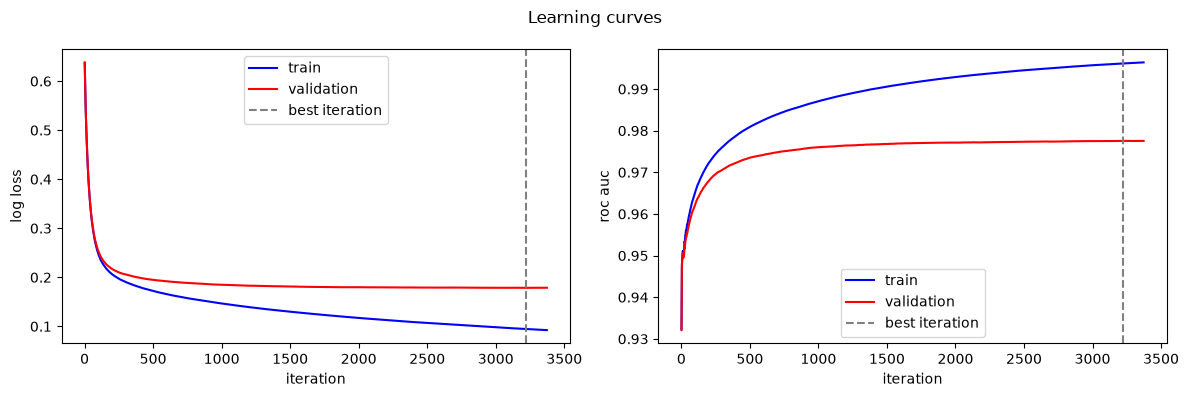

snapshot 2016-11-01, catboost, engineered features, k 2, best iteration 2096, validation log loss at best 0.1751, train 0.0807


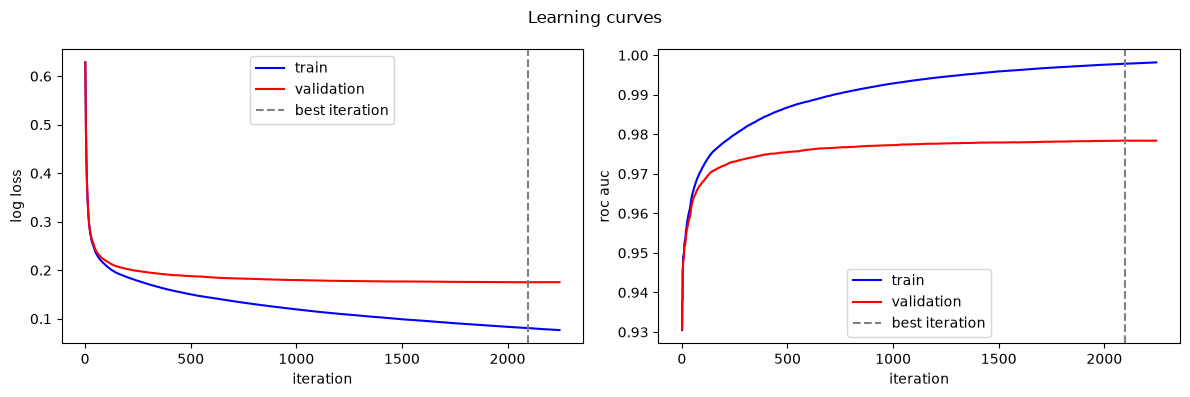

snapshot 2016-06-22, lgbm best, k 1, engineered features, k 1, best iteration 1262, validation log loss at best 0.1694, train 0.0957


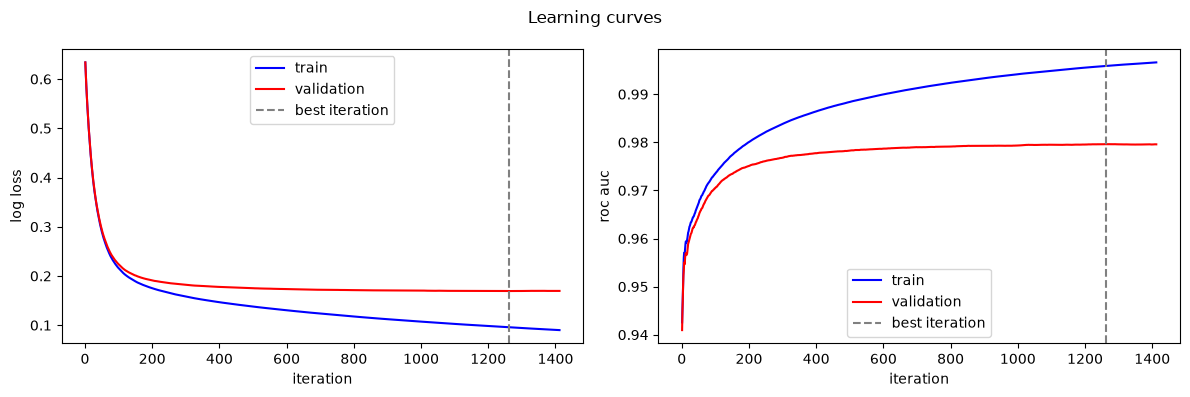

snapshot 2016-06-22, lgbm best, k 3, engineered features, k 3, best iteration 1561, validation log loss at best 0.1715, train 0.0837


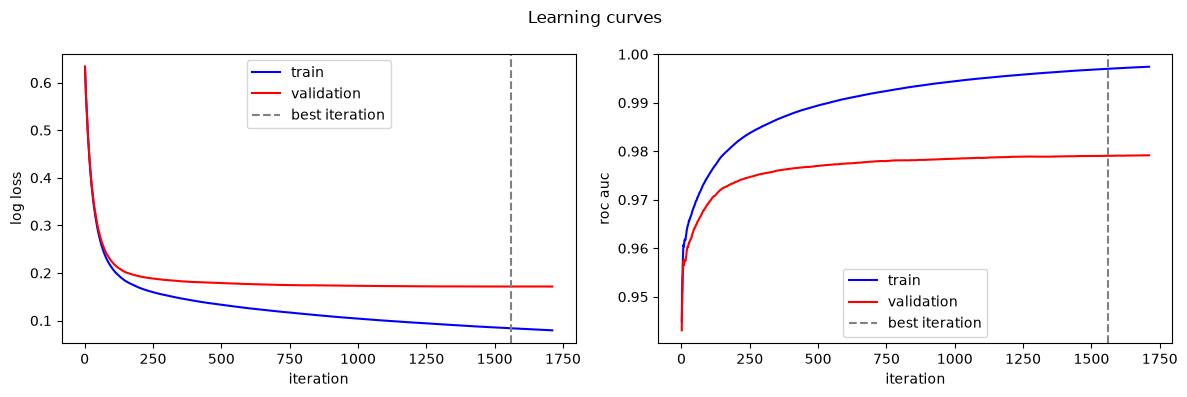

In [24]:
for key, curve in curves.items():
    if curve is None:
        continue
    print("snapshot " + key[0] + ", " + key[1] + ", " + key[2] + " features, k " + str(key[3]) + ", best iteration " + str(curve["best_iteration"]) + ", validation log loss at best " + str(round(curve["test_loss"][curve["best_iteration"] - 1], 4)) + ", train " + str(round(curve["train_loss"][curve["best_iteration"] - 1], 4)))
    plot_learning_curves(curve)

In [25]:
table = results_table(results)
pd.set_option("display.width", 220)
print(table.sort_values(["snapshot", "future_brier"]).to_string(index=False))
with open(os.path.join(MODELS_DIR, "experiments_cancellation.json"), "w") as f:
    json.dump(results, f, indent=1)
print("saved " + os.path.join(MODELS_DIR, "experiments_cancellation.json"))

  snapshot                                name   features  k  seconds  on_books_auc  on_books_brier  on_books_ece  future_auc  future_brier  future_ece  near_arrivals_auc  near_arrivals_brier  near_arrivals_ece
2016-06-22 ensemble lgbm + catboost + logistic engineered  2        0        0.9208          0.0968        0.0603      0.8699        0.1423      0.0479             0.9118               0.1165             0.0573
2016-06-22                       lgbm search 4 engineered  2       25        0.9250          0.0974        0.0686      0.8717        0.1459      0.0655             0.9201               0.1174             0.0733
2016-06-22                        lgbm default engineered  2       23        0.9233          0.0997        0.0717      0.8736        0.1472      0.0810             0.9194               0.1152             0.0678
2016-06-22                      lgbm best, k 3 engineered  3       53        0.9256          0.0955        0.0640      0.8718        0.1472      0.0696     